<a href="https://colab.research.google.com/github/khietvuarong/Group-Exercise_-Agentic-AI-in-Supply-Chain/blob/main/Agentic_AI_in_Supply_Chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##

In [33]:
!pip install openai

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from google.colab import userdata
from openai import OpenAI

client = OpenAI(api_key=userdata.get("OpenAiAPI"))

np.random.seed(42)


##Adapt the code to auto-generate data


In [35]:
n_days = 90
skus = ["SKU_A", "SKU_B", "SKU_C"]
dates = pd.date_range(start="2023-01-01", periods=n_days)

# Sales
sales_data = []
for sku in skus:
    base = np.random.randint(15, 40)
    for date in dates:
        demand = max(0, int(np.random.normal(base, 5)))
        sales_data.append([date, sku, demand])

sales_df = pd.DataFrame(sales_data, columns=["date", "sku", "qty_sold"])
sales_df.to_csv("sales.csv", index=False)

# Inventory
inventory_df = pd.DataFrame({
    "sku": skus,
    "opening_stock": np.random.randint(80, 150, len(skus))
})
inventory_df.to_csv("inventory.csv", index=False)

# Params
params_data = []
for sku in skus:
    unit_cost = np.random.uniform(5, 20)
    params_data.append([
        sku,
        unit_cost,
        unit_cost * 0.01,
        unit_cost * 5,
        np.random.randint(2, 6),
        np.random.randint(20, 50),
        np.random.choice([0.90, 0.95, 0.98])
    ])

params_df = pd.DataFrame(params_data, columns=[
    "sku","unit_cost","holding_cost_per_day","stockout_cost",
    "lead_time_days","min_order_qty","service_level"
])
params_df.to_csv("params.csv", index=False)

#Load the data

In [36]:
sales = pd.read_csv("sales.csv", parse_dates=["date"])
inventory = pd.read_csv("inventory.csv")
params = pd.read_csv("params.csv")

sales = sales.groupby(["date","sku"])["qty_sold"].sum().reset_index()

##Forecast + Safety stock (EWMA)






In [37]:
def ewma(series, alpha=0.3):
    f = [series.iloc[0]]
    for i in range(1, len(series)):
        f.append(alpha * series.iloc[i-1] + (1-alpha)*f[-1])
    return np.array(f)

def safety_stock(errors, service_level, lead_time):
    z = norm.ppf(service_level)
    return z * np.std(errors) * np.sqrt(lead_time)

##LLM function and Agent simulation with LLM




In [38]:
def explain_llm(context):
    if client is None:
        return "LLM disabled"

    prompt = f"""
    Explain briefly why the inventory agent made this decision.

    Stock: {context['stock']}
    Demand: {context['demand']}
    Forecast: {context['forecast']}
    Inventory Position: {context['inventory_position']}
    Reorder Point: {context['rop']}
    Action: {context['action']}
    """

    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3
    )

    return response.choices[0].message.content

def run_agent():
    results = []
    logs = []
    traces = []

    for sku in params["sku"]:
        d = sales[sales["sku"]==sku].sort_values("date")
        demand = d["qty_sold"].values
        dates = d["date"].values

        p = params[params["sku"]==sku].iloc[0]

        lead = int(p["lead_time_days"])
        hold = p["holding_cost_per_day"]
        stockout_cost = p["stockout_cost"]
        min_q = int(p["min_order_qty"])
        sl = p["service_level"]

        forecast = ewma(pd.Series(demand))
        errors = demand - forecast
        ss = safety_stock(errors, sl, lead)

        stock = inventory[inventory["sku"]==sku]["opening_stock"].values[0]
        pipeline = []

        total_demand = 0
        fulfilled = 0
        hold_cost = 0
        stockout_total = 0

        print(f"\n=== {sku} ===")

        for t in range(len(demand)):

            # receive
            arrivals = [o for o in pipeline if o[0]==t]
            for _,q in arrivals:
                stock += q
            pipeline = [o for o in pipeline if o[0]>t]

            today = demand[t]
            total_demand += today

            if stock >= today:
                stock -= today
                fulfilled += today
                so = 0
            else:
                so = today - stock
                fulfilled += stock
                stock = 0

            stockout_total += so
            hold_cost += stock * hold

            inv_pos = stock + sum(q for _,q in pipeline)
            rop = forecast[t]*lead + ss

            action = "WAIT"

            if inv_pos < rop:
                qty = max(min_q, int(rop - inv_pos))
                pipeline.append((t+lead, qty))
                action = f"ORDER {qty}"

            # LLM (only when ordering to save cost)
            if "ORDER" in action:
                explanation = explain_llm({
                    "stock": stock,
                    "demand": today,
                    "forecast": forecast[t],
                    "inventory_position": inv_pos,
                    "rop": rop,
                    "action": action
                })
            else:
                explanation = "No action needed"

            print(f"Day {t} | Stock={stock} | Action={action}")
            print("AI:", explanation)

            logs.append({
                "date": dates[t],
                "sku": sku,
                "stock": stock,
                "action": action,
                "llm": explanation
            })

            traces.append({
                "date": dates[t],
                "sku": sku,
                "stock": stock,
                "forecast": forecast[t]
            })

        results.append({
            "sku": sku,
            "fill_rate": fulfilled/total_demand,
            "total_cost": hold_cost + stockout_total*stockout_cost,
            "stockouts": stockout_total
        })

    return pd.DataFrame(results), pd.DataFrame(logs), pd.DataFrame(traces)

#Baseline

In [39]:
def run_baseline():
    results = []

    for sku in params["sku"]:
        d = sales[sales["sku"]==sku].sort_values("date")
        demand = d["qty_sold"].values

        p = params[params["sku"]==sku].iloc[0]

        stock = inventory[inventory["sku"]==sku]["opening_stock"].values[0]
        lead = int(p["lead_time_days"])
        hold = p["holding_cost_per_day"]
        stockout_cost = p["stockout_cost"]
        min_q = int(p["min_order_qty"])

        pipeline=[]
        total_demand=0
        fulfilled=0
        hold_cost=0
        stockouts=0

        for t in range(len(demand)):
            arrivals=[o for o in pipeline if o[0]==t]
            for _,q in arrivals:
                stock+=q
            pipeline=[o for o in pipeline if o[0]>t]

            dmd=demand[t]
            total_demand+=dmd

            if stock>=dmd:
                stock-=dmd
                fulfilled+=dmd
            else:
                stockouts+=dmd-stock
                fulfilled+=stock
                stock=0

            hold_cost+=stock*hold

            if stock<50:
                pipeline.append((t+lead, max(min_q,50-stock)))

        results.append({
            "sku":sku,
            "fill_rate":fulfilled/total_demand,
            "total_cost":hold_cost+stockouts*stockout_cost
        })

    return pd.DataFrame(results)

##Execute the Agent (Will take a little long)



In [40]:
agent_res, logs, traces = run_agent()
baseline_res = run_baseline()

print("\nAGENT")
display(agent_res)

print("\nBASELINE")
display(baseline_res)


=== SKU_A ===
Day 0 | Stock=84 | Action=ORDER 29
AI: The inventory agent decided to order 29 units because the current inventory position (84) is below the reorder point (108.65). The reorder point is set to ensure enough stock to meet expected demand plus safety stock. Since 84 < 108.65, the agent places an order to raise inventory closer to the target level, hence ordering 29 units.
Day 1 | Stock=61 | Action=ORDER 29
AI: The inventory agent decided to order 29 units because the current inventory position (90) is below the reorder point (108.65). The reorder point is set to ensure enough stock to meet expected demand plus safety stock. Since 90 < 108.65, the agent places an order to raise the inventory position closer to or above the reorder point, helping to prevent stockouts. The order quantity of 29 units likely brings the inventory position closer to the target level.
Day 2 | Stock=38 | Action=ORDER 29
AI: The inventory agent decided to order 29 units because the current inventor

,sku,fill_rate,total_cost,stockouts
0,SKU_A,0.991909,1915.665544,15
1,SKU_B,0.953151,13556.842025,139
2,SKU_C,0.988870,3075.848655,32



BASELINE


,sku,fill_rate,total_cost
0,SKU_A,0.855987,25386.411503
1,SKU_B,0.734075,75526.959529
2,SKU_C,0.784696,47870.135926


##Visualized Dashboard

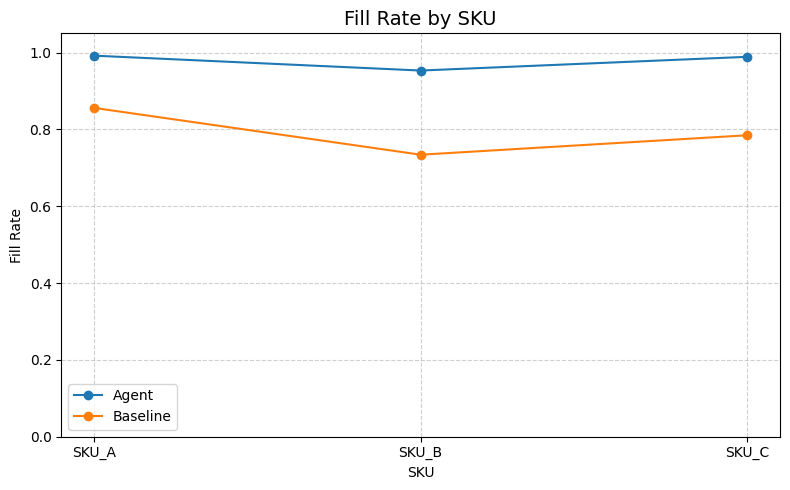

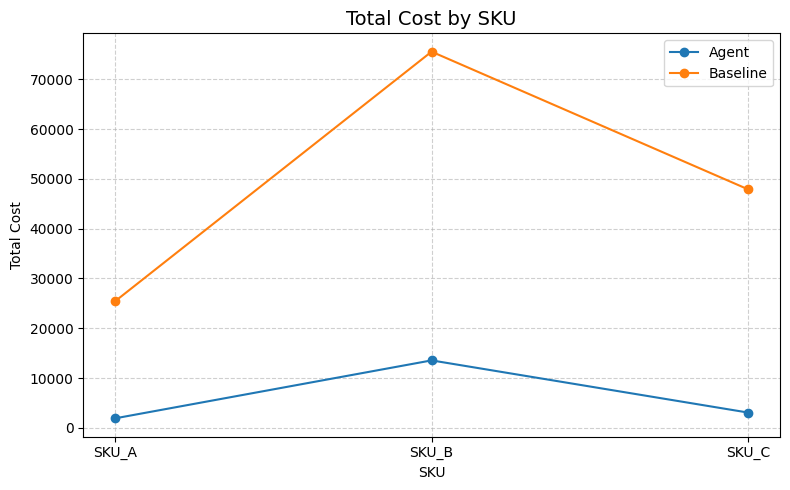

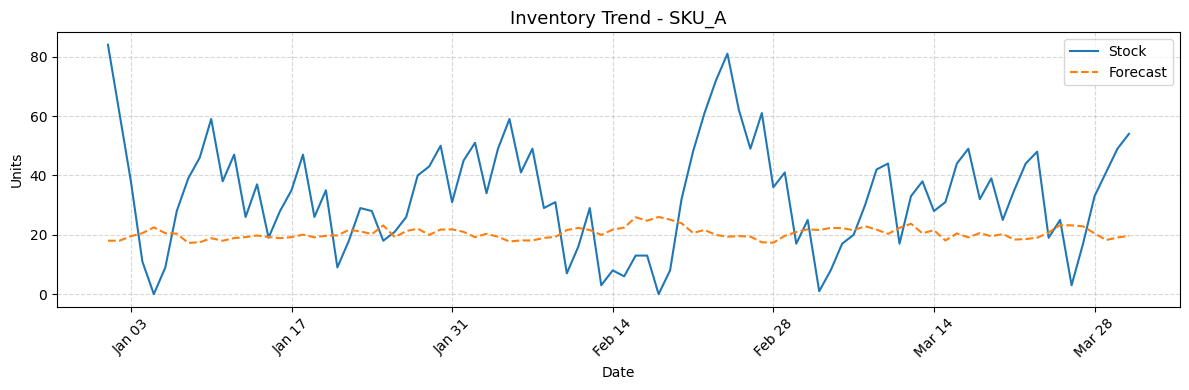

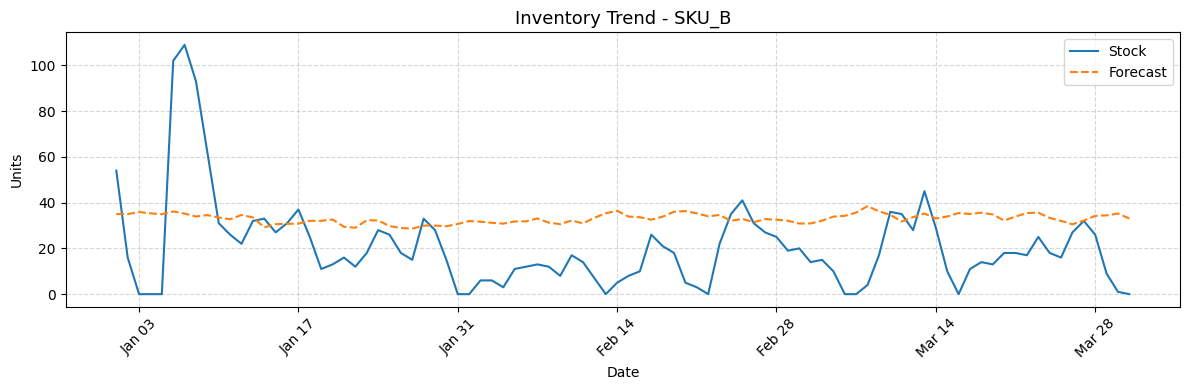

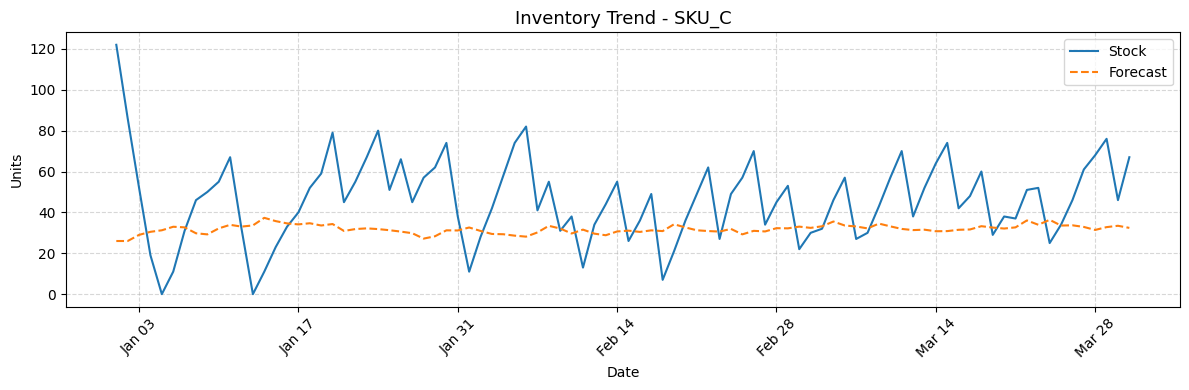

In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure datetime format
traces["date"] = pd.to_datetime(traces["date"])
plt.style.use('default')

# ----------------------------
# 1. Fill Rate Comparison
# ----------------------------
plt.figure(figsize=(8,5))
plt.plot(agent_res["sku"], agent_res["fill_rate"], marker='o', label="Agent")
plt.plot(baseline_res["sku"], baseline_res["fill_rate"], marker='o', label="Baseline")

plt.title("Fill Rate by SKU", fontsize=14)
plt.xlabel("SKU")
plt.ylabel("Fill Rate")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 2. Cost Comparison
# ----------------------------
plt.figure(figsize=(8,5))
plt.plot(agent_res["sku"], agent_res["total_cost"], marker='o', label="Agent")
plt.plot(baseline_res["sku"], baseline_res["total_cost"], marker='o', label="Baseline")

plt.title("Total Cost by SKU", fontsize=14)
plt.xlabel("SKU")
plt.ylabel("Total Cost")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 3. Inventory Trend (FIXED DATES)
# ----------------------------
for sku in traces["sku"].unique():
    sub = traces[traces["sku"] == sku].sort_values("date")

    fig, ax = plt.subplots(figsize=(12,4))

    ax.plot(sub["date"], sub["stock"], label="Stock")
    ax.plot(sub["date"], sub["forecast"], label="Forecast", linestyle="--")

    ax.set_title(f"Inventory Trend - {sku}", fontsize=13)
    ax.set_xlabel("Date")
    ax.set_ylabel("Units")

    # Fix date formatting
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # every 2 weeks
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

    plt.xticks(rotation=45)

    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()

    plt.tight_layout()
    plt.show()



In [42]:
logs.to_csv("agent_logs.csv", index=False)